In [ ]:
# # This Python 3 environment comes with many helpful analytics libraries installed
# # It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# # For example, here's several helpful packages to load

# import numpy as np # linear algebra
# import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# # Input data files are available in the read-only "../input/" directory
# # For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

# import os
# for dirname, _, filenames in os.walk('/kaggle/input'):
#     for filename in filenames:
#         print(os.path.join(dirname, filename))

# # You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# # You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [237]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import MinMaxScaler, StandardScaler, OneHotEncoder, OrdinalEncoder, LabelEncoder

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score, recall_score, roc_auc_score, roc_curve

In [238]:
pd.set_option('display.max_columns', None)

In [ ]:
# df = pd.read_csv('/kaggle/input/competitions/playground-series-s6e3/train.csv')
# test_data = pd.read_csv('/kaggle/input/competitions/playground-series-s6e3/test.csv')

In [ ]:
df = pd.read_csv("train.csv")
df.shape

(594194, 21)

In [240]:
df.head()

,id,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,Male,0,Yes,Yes,29,Yes,No,DSL,Yes,No,Yes,Yes,No,No,One year,Yes,Mailed check,60.10,1653.85,No
1,1,Male,0,Yes,Yes,58,Yes,No,DSL,Yes,Yes,No,Yes,Yes,No,Two year,No,Credit card (automatic),69.50,3778.20,No
2,2,Male,0,Yes,No,58,Yes,Yes,Fiber optic,No,Yes,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,100.40,5841.35,No
3,3,Female,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,69.70,70.70,Yes
4,4,Female,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.45,70.45,Yes


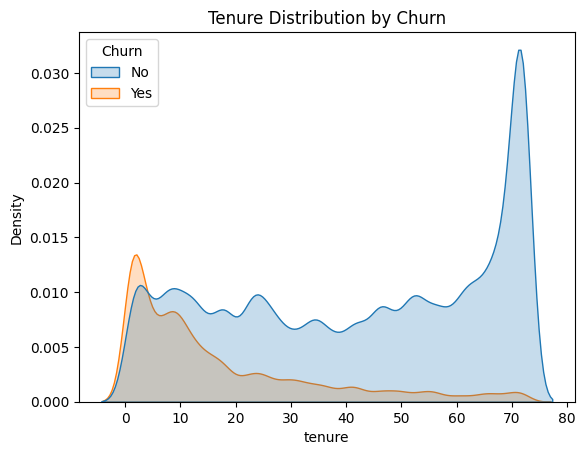

In [241]:

sns.kdeplot(data=df, x="tenure", hue="Churn", fill=True)

plt.title("Tenure Distribution by Churn")
plt.show()

In [242]:
df["tenure"].max()

np.int64(72)

In [243]:
df["tenure_group"] = pd.cut(
    df["tenure"],
    bins=[0,10,20,30,40,50,60,70,80],
    labels=["0-10", "10-20", "20-30", "30-40","40-50", "50-60", "60-70", "70+"]
    # bins=[0, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70, 75],
    # labels=["0-5", "5-10", "10-15", "15-20", "20-25", "25-30", "30-35", "35-40","40-45", "45-50", "50-55", "55-60", "60-65", "65-70", "70+"]
)



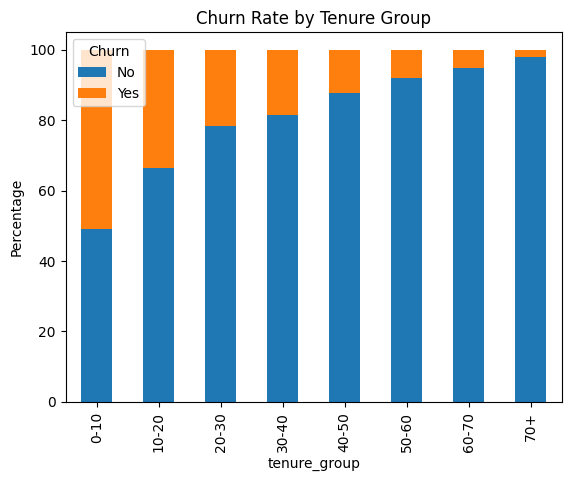

In [244]:
tenure_churn = pd.crosstab(df["tenure_group"], df["Churn"], normalize="index") * 100

tenure_churn.plot(kind="bar", stacked=True)

plt.title("Churn Rate by Tenure Group")
plt.ylabel("Percentage")
plt.show()

In [245]:
df[["tenure", "tenure_group"]]

,tenure,tenure_group
0,29,20-30
1,58,50-60
2,58,50-60
3,1,0-10
4,1,0-10
...,...,...
594189,57,50-60
594190,72,70+
594191,72,70+
594192,32,30-40


In [246]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 594194 entries, 0 to 594193
Data columns (total 22 columns):
 #   Column            Non-Null Count   Dtype   
---  ------            --------------   -----   
 0   id                594194 non-null  int64   
 1   gender            594194 non-null  str     
 2   SeniorCitizen     594194 non-null  int64   
 3   Partner           594194 non-null  str     
 4   Dependents        594194 non-null  str     
 5   tenure            594194 non-null  int64   
 6   PhoneService      594194 non-null  str     
 7   MultipleLines     594194 non-null  str     
 8   InternetService   594194 non-null  str     
 9   OnlineSecurity    594194 non-null  str     
 10  OnlineBackup      594194 non-null  str     
 11  DeviceProtection  594194 non-null  str     
 12  TechSupport       594194 non-null  str     
 13  StreamingTV       594194 non-null  str     
 14  StreamingMovies   594194 non-null  str     
 15  Contract          594194 non-null  str     
 16  PaperlessBill

In [247]:
df.isnull().sum()

id                  0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
tenure_group        0
dtype: int64

In [248]:
object_cols = df.select_dtypes(include='object').columns
object_cols

/var/folders/gx/5977vg1j77q10smlkkwzkw4m0000gn/T/ipykernel_57282/4015107672.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  object_cols = df.select_dtypes(include='object').columns


Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'Churn'],
      dtype='str')

In [249]:
num_cols = df.select_dtypes(exclude='object').columns
num_cols

Index(['id', 'SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges',
       'tenure_group'],
      dtype='str')

In [250]:
categorical_columns = ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',\
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',\
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',\
       'PaperlessBilling', 'PaymentMethod', 'SeniorCitizen', "tenure_group"]

#numerical_columns = ['tenure', 'MonthlyCharges', 'TotalCharges']
numerical_columns = ['MonthlyCharges', 'TotalCharges']

target_column = ["Churn"]

### lets check target column distribution

In [251]:
churn_dist = df[target_column].value_counts().to_frame()
churn_dist["percentage"] = (churn_dist["count"]/ df.shape[0]*100).round(2)
churn_dist

,count,percentage
Churn,,
No,460377,77.48
Yes,133817,22.52


In [252]:
print(f"Churn Ration:\nChurn: No Churn = {churn_dist["percentage"].iloc[1]/churn_dist["percentage"].iloc[1]}: {(churn_dist["percentage"].iloc[0]/ churn_dist["percentage"].iloc[1]).round(2)}")

Churn Ration:
Churn: No Churn = 1.0: 3.44


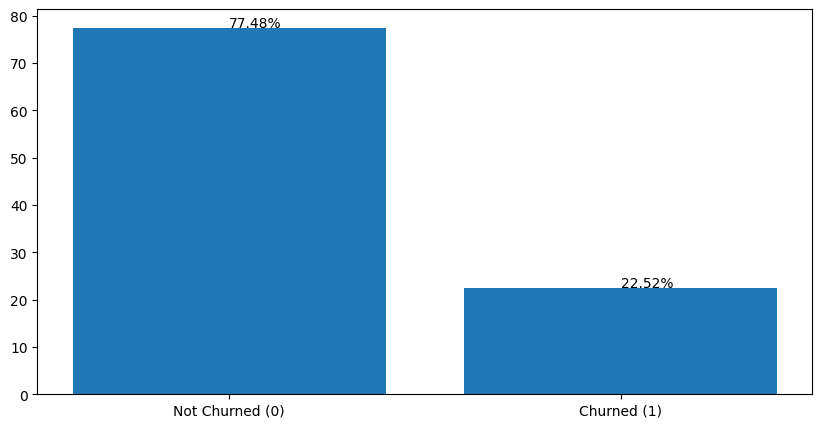

In [253]:
fig, ax = plt.subplots(figsize=(10,5))
ax.bar(['Not Churned (0)', 'Churned (1)'], churn_dist["percentage"])
for i, col in enumerate(churn_dist["percentage"]):
    ax.text(i, col+0.05, f"{col}%")



## Target distribution is imbalance, churn to no churn ratio is 1:3.44. Need to consider this during training the model

# Numerical column analysis - Univariate and Bivariant 

In [254]:
# fig, axes = plt.subplots(2,2, figsize = (14,6))
# axes = axes.flatten()
# for i, col in enumerate(numerical_columns):
#     axes[i].hist(df[col], bins = 50)

#     mean = (df[col].mean()).round(2)
#     median = (df[col].median()).round(2)

#     axes[i].axvline(mean, color = 'red', linestyle="--", label=f"Mean:{mean}")
#     axes[i].axvline(median, color='green', linestyle = "-", label = f"Median:{median}")

#     axes[i].set_title(col)
#     axes[i].legend()

# for j in range(len(numerical_columns), len(axes)):
#     axes[j].set_visible(False)


#### Check for outliers

In [255]:
# fig, axes = plt.subplots(2,2, figsize = (24,10))
# axes = axes.flatten()
# for i, col in enumerate(numerical_columns):
#     sns.boxplot(df[col], ax=axes[i], color="green", label="overall distribution")
#     sns.boxplot(data=df, x="Churn", y=col, ax=axes[i], label = "churn vs. No churn distribution")
    
#     axes[i].set_title(col)
#     axes[i].grid()
#     axes[i].plot()
#     axes[i].legend()

# for j in range(len(numerical_columns), len(axes)):
#     axes[j].set_visible(False)

# #sns.boxplot(df[col])

In [256]:
churned = df[df["Churn"] == 'Yes']
not_churned = df[df["Churn"] == 'No']

In [257]:
# fig, axes = plt.subplots(2,2,figsize=(16,8))
# axes = axes.flatten()

# for i, col in enumerate(numerical_columns):
#     sns.histplot(not_churned[col], ax= axes[i], label = "not churned")
#     sns.histplot(churned[col], ax=axes[i], label = "churned")

#     axes[i].set_title(col)
#     axes[i].legend()

# for j in range(len(numerical_columns), len(axes)):
#     axes[j].set_visible(None)

<Figure size 1600x1200 with 0 Axes>

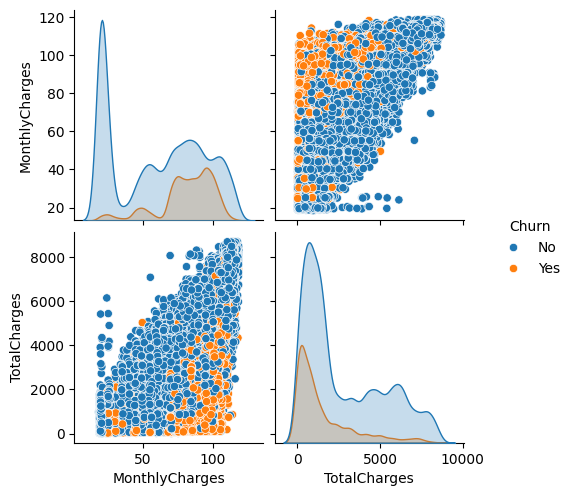

In [258]:
plt.figure(figsize = (16,12))
sns.pairplot(df.sample(frac=0.1)[numerical_columns+ target_column], hue="Churn")

- For "monthlycharge" and "totalcharges" there is significance difference in mean and median, that means these 2 are skewed.
- All 3 numerical columns contains significant number of outliers for Churned customers. there is no outliers for not churned.
- As tenure increases churn rate decreases. same for "Total charges".
- not much relationships between the numeric columns

## Categorical Columns

In [259]:
categorical_columns

['gender',
 'Partner',
 'Dependents',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'SeniorCitizen',
 'tenure_group']

### Distribution of Categorical columns

In [260]:
# fig, axes = plt.subplots(6,3, figsize=(20,30))
# axes = axes.flatten()

# for i, col in enumerate(categorical_columns):
#     value_counts = (df[col].value_counts(normalize=True)*100).round(2)
#     axes[i].bar(value_counts.index, value_counts.values)

#     axes[i].set_xlabel(col)
#     axes[i].set_ylabel("Percentage")

#     for x, y in zip(value_counts.index, value_counts.values):
#         axes[i].text(x, y+0.5, f"{y}%", ha="center")
    
#     for j in range(len(categorical_columns), len(axes)):
#         axes[j].set_visible(None)



In [261]:
# fig, axes = plt.subplots(6,3, figsize = (20,40))
# axes = axes.flatten()

# for i, col in enumerate(categorical_columns):
#     churn_distribution = (pd.crosstab(df[col], df["Churn"], normalize="index")*100).round(2)
#     churn_distribution.plot(kind='bar', stacked=True, ax=axes[i])

#     for container in axes[i].containers:
#         axes[i].bar_label(container, fmt='%.1f%%')

#     axes[i].tick_params(axis = 'x', rotation=0)
#     axes[i].set_ylabel("percentage")

# for j in range(len(categorical_columns), len(axes)):
#     axes[j].set_visible(None)

### Looks Churn rate does not depend on gender, churn rate depends on all other categorical columns

In [262]:
def encode_binary_columns(col):
    classes_ = np.unique(df[col])
    df[col] = np.where(df[col] == classes_[0], 0, 1)


In [263]:

binary_cols = ["Churn", "Partner", "Dependents", "PhoneService", "PaperlessBilling"]
for col in binary_cols:
    encode_binary_columns(col)

In [264]:
df.corr(numeric_only=True)["Churn"].sort_values(ascending=False)

Churn               1.000000
PaperlessBilling    0.285107
MonthlyCharges      0.272997
SeniorCitizen       0.236362
PhoneService        0.034843
id                 -0.012971
TotalCharges       -0.218365
Partner            -0.228212
Dependents         -0.240369
tenure             -0.418453
Name: Churn, dtype: float64

In [265]:
X = df.drop(["id", "Churn"], axis=1)
y = df["Churn"]

In [266]:
X.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,tenure_group
0,Male,0,1,1,29,1,No,DSL,Yes,No,Yes,Yes,No,No,One year,1,Mailed check,60.10,1653.85,20-30
1,Male,0,1,1,58,1,No,DSL,Yes,Yes,No,Yes,Yes,No,Two year,0,Credit card (automatic),69.50,3778.20,50-60
2,Male,0,1,0,58,1,Yes,Fiber optic,No,Yes,No,No,Yes,Yes,Month-to-month,1,Electronic check,100.40,5841.35,50-60
3,Female,0,0,0,1,1,No,Fiber optic,No,No,No,No,No,No,Month-to-month,1,Electronic check,69.70,70.70,0-10
4,Female,0,0,0,1,1,No,Fiber optic,No,No,No,No,No,No,Month-to-month,1,Electronic check,70.45,70.45,0-10


In [267]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=9)

In [268]:
## encode categorical columns for XGBoost

#cat_cols_ordinal = ["MultipleLines", "InternetService", "OnlineSecurity", "OnlineBackup", "DeviceProtection", "TechSupport", "StreamingTV", "StreamingMovies", "Contract"]
cat_cols_onehotencoding = ["gender", "PaymentMethod", "tenure_group", "MultipleLines", "InternetService", "OnlineSecurity", "OnlineBackup", "DeviceProtection", "TechSupport", "StreamingTV", "StreamingMovies", "Contract"]
pass_through_cols = ["Partner", "Dependents", "PhoneService", "PaperlessBilling", "SeniorCitizen"]



preprocessor_xgboost = ColumnTransformer(
    transformers=[
        ("StandardScaler", StandardScaler(), numerical_columns),
        ("OneHotEncoder", OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols_onehotencoding),
        #("OrdinalEncoder", OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), cat_cols_ordinal),
        ("pass", "passthrough", pass_through_cols)
        ]
)

In [269]:
X_train.iloc[0,:]

gender                        Male
SeniorCitizen                    0
Partner                          1
Dependents                       1
tenure                           3
PhoneService                     1
MultipleLines                   No
InternetService        Fiber optic
OnlineSecurity                 Yes
OnlineBackup                    No
DeviceProtection                No
TechSupport                     No
StreamingTV                     No
StreamingMovies                 No
Contract            Month-to-month
PaperlessBilling                 1
PaymentMethod         Mailed check
MonthlyCharges                74.9
TotalCharges                220.45
tenure_group                  0-10
Name: 159875, dtype: object

### XGBoost

In [270]:
X_train_xgb = preprocessor_xgboost.fit_transform(X_train)
X_test_xgb = preprocessor_xgboost.transform(X_test)

In [271]:
X_train_xgb[0]

array([ 0.29052368, -0.96583187,  0.        ,  1.        ,  0.        ,
        0.        ,  0.        ,  1.        ,  1.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  1.        ,  0.        ,  0.        ,  0.        ,
        1.        ,  0.        ,  0.        ,  0.        ,  1.        ,
        1.        ,  0.        ,  0.        ,  1.        ,  0.        ,
        0.        ,  1.        ,  0.        ,  0.        ,  1.        ,
        0.        ,  0.        ,  1.        ,  0.        ,  0.        ,
        1.        ,  0.        ,  0.        ,  1.        ,  1.        ,
        1.        ,  1.        ,  0.        ])

In [272]:
from xgboost import XGBClassifier


xgb = XGBClassifier(eval_matrics = 'auc', n_estimator = 500, learning_rate=0.05, max_depth=4, random_state=42)
xgb.fit(X_train_xgb, y_train)

p_xgb = xgb.predict_proba(X_test_xgb)[:,1]
print("XGBoost Test AUC:", roc_auc_score(y_test, p_xgb))


/Users/sumana/Desktop/AIML/.venv/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [10:29:41] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "eval_matrics", "n_estimator" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost Test AUC: 0.9115798527081311


In [273]:
# Randomized search for XGBoost
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from scipy.stats import randint, uniform

xgb_param_dist = {
    'n_estimators': randint(100, 500),
    'learning_rate': uniform(0.01, 0.2),
    'max_depth': randint(3, 8),
    'subsample': uniform(0.6, 0.4),
    'colsample_bytree': uniform(0.6, 0.4),
    'reg_alpha': uniform(0, 1),
    'reg_lambda': uniform(0.5, 2)
}

xgb_clf = XGBClassifier(eval_metric='auc', random_state=42)

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
rs_xgb = RandomizedSearchCV(xgb_clf, param_distributions=xgb_param_dist, n_iter=25, scoring='roc_auc', cv=cv, verbose=2, n_jobs=-1, random_state=42)
rs_xgb.fit(X_train_xgb, y_train)
print("Best XGB params:", rs_xgb.best_params_)
print("Best XGB CV AUC:", rs_xgb.best_score_)



Fitting 3 folds for each of 25 candidates, totalling 75 fits
[CV] END colsample_bytree=0.749816047538945, learning_rate=0.20014286128198325, max_depth=5, n_estimators=171, reg_alpha=0.5986584841970366, reg_lambda=0.812037280884873, subsample=0.662397808134481; total time=   6.5s
[CV] END colsample_bytree=0.749816047538945, learning_rate=0.20014286128198325, max_depth=5, n_estimators=171, reg_alpha=0.5986584841970366, reg_lambda=0.812037280884873, subsample=0.662397808134481; total time=   6.6s
[CV] END colsample_bytree=0.749816047538945, learning_rate=0.20014286128198325, max_depth=5, n_estimators=171, reg_alpha=0.5986584841970366, reg_lambda=0.812037280884873, subsample=0.662397808134481; total time=   6.6s
[CV] END colsample_bytree=0.6092249700165663, learning_rate=0.11495493205167782, max_depth=4, n_estimators=287, reg_alpha=0.3663618432936917, reg_lambda=1.4121399684340719, subsample=0.9140703845572055; total time=   8.8s
[CV] END colsample_bytree=0.6798695128633439, learning_rate=

In [274]:
best_xgb = rs_xgb.best_estimator_
p_xgb_best = best_xgb.predict_proba(X_test_xgb)[:,1]
print("Tuned XGBoost Test AUC:", roc_auc_score(y_test, p_xgb_best))

Tuned XGBoost Test AUC: 0.9147638527966815


### LightGBM

In [275]:
## encode categorical columns for XGBoost

cat_cols_ordinal_lgb = ["MultipleLines", "InternetService", "OnlineSecurity", "OnlineBackup", "DeviceProtection", "TechSupport", "StreamingTV", "StreamingMovies", "Contract"]
cat_cols_onehotencoding_lgb = ["gender", "PaymentMethod", "tenure_group"]
pass_through_cols_lgb = ["Partner", "Dependents", "PhoneService", "PaperlessBilling", "SeniorCitizen"]



preprocessor_lgb = ColumnTransformer(
    transformers=[
        #("StandardScaler", StandardScaler(), numerical_columns),
        #("OneHotEncoder", OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols_onehotencoding),
        ("OrdinalEncoder", OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), cat_cols_ordinal_lgb)
        #("pass", "passthrough", pass_through_cols)
        ]
)

In [276]:
X_train_lgb = preprocessor_lgb.fit_transform(X_train)
X_test_lgb = preprocessor_lgb.transform(X_test)

In [277]:
# Train LightGBM (requires lightgbm installed)
import lightgbm as lgb

lgb_clf = lgb.LGBMClassifier(n_estimators=500, learning_rate=0.05, random_state=42)
# Use ordinal encoded arrays
lgb_clf.fit(X_train_lgb, y_train, eval_set=[(X_test_lgb, y_test)], eval_metric='auc')
print("LightGBM Test AUC:", roc_auc_score(y_test, lgb_clf.predict_proba(X_test_lgb)[:,1]))

[LightGBM] [Info] Number of positive: 107054, number of negative: 368301
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002318 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 27
[LightGBM] [Info] Number of data points in the train set: 475355, number of used features: 9
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.225209 -> initscore=-1.235567
[LightGBM] [Info] Start training from score -1.235567


/Users/sumana/Desktop/AIML/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


LightGBM Test AUC: 0.8824438940721145


## CatBoost

In [278]:
X_train["tenure"]

159875     3
508573    55
407413    72
208082     6
15581      6
          ..
89295     59
512603    14
453005     6
573991    71
122619    34
Name: tenure, Length: 475355, dtype: int64

In [279]:
X_train

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,tenure_group
159875,Male,0,1,1,3,1,No,Fiber optic,Yes,No,No,No,No,No,Month-to-month,1,Mailed check,74.90,220.45,0-10
508573,Male,0,1,1,55,1,Yes,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,1,Credit card (automatic),79.40,5309.65,50-60
407413,Male,0,1,0,72,1,Yes,Fiber optic,Yes,Yes,Yes,Yes,Yes,Yes,Two year,1,Credit card (automatic),113.65,8016.60,70+
208082,Male,1,0,0,6,1,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,1,Electronic check,78.85,527.55,0-10
15581,Male,0,0,0,6,1,Yes,Fiber optic,No,No,No,No,No,Yes,Month-to-month,1,Electronic check,83.85,438.60,0-10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
89295,Male,0,1,0,59,1,No,Fiber optic,No,Yes,Yes,Yes,Yes,No,One year,0,Credit card (automatic),95.50,5199.80,50-60
512603,Female,0,1,1,14,1,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,0,Bank transfer (automatic),20.45,292.40,10-20
453005,Male,1,0,0,6,1,Yes,Fiber optic,No,Yes,No,No,Yes,Yes,Month-to-month,1,Electronic check,100.45,574.45,0-10
573991,Male,0,1,0,71,1,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,0,Bank transfer (automatic),24.75,1715.10,70+


In [280]:
## encode categorical columns for XGBoost

# cat_cols_ordinal_lgb = ["MultipleLines", "InternetService", "OnlineSecurity", "OnlineBackup", "DeviceProtection", "TechSupport", "StreamingTV", "StreamingMovies", "Contract"]
# cat_cols_onehotencoding_lgb = ["gender", "PaymentMethod", "tenure_group"]
# pass_through_cols_lgb = ["Partner", "Dependents", "PhoneService", "PaperlessBilling", "SeniorCitizen"]



preprocessor_cb = ColumnTransformer(
    transformers=[
        ("StandardScaler", StandardScaler(), numerical_columns),
        ("pass", "passthrough", categorical_columns)
        ]
)

In [301]:
#preprocessor_cb.set_output(transform="pandas")
X_train_cb = preprocessor_cb.fit_transform(X_train)
X_test_cb = preprocessor_cb.transform(X_test)

In [303]:
X_train_cb.head()

,StandardScaler__MonthlyCharges,StandardScaler__TotalCharges,pass__gender,pass__Partner,pass__Dependents,pass__PhoneService,pass__MultipleLines,pass__InternetService,pass__OnlineSecurity,pass__OnlineBackup,pass__DeviceProtection,pass__TechSupport,pass__StreamingTV,pass__StreamingMovies,pass__Contract,pass__PaperlessBilling,pass__PaymentMethod,pass__SeniorCitizen,pass__tenure_group
159875,0.290524,-0.965832,Male,1,1,1,No,Fiber optic,Yes,No,No,No,No,No,Month-to-month,1,Mailed check,0,0-10
508573,0.435387,1.195091,Male,1,1,1,Yes,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,1,Credit card (automatic),0,50-60
407413,1.537956,2.344488,Male,1,0,1,Yes,Fiber optic,Yes,Yes,Yes,Yes,Yes,Yes,Two year,1,Credit card (automatic),0,70+
208082,0.417681,-0.835434,Male,0,0,1,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,1,Electronic check,1,0-10
15581,0.578640,-0.873203,Male,0,0,1,Yes,Fiber optic,No,No,No,No,No,Yes,Month-to-month,1,Electronic check,0,0-10


In [304]:
X_test_cb.head()

,StandardScaler__MonthlyCharges,StandardScaler__TotalCharges,pass__gender,pass__Partner,pass__Dependents,pass__PhoneService,pass__MultipleLines,pass__InternetService,pass__OnlineSecurity,pass__OnlineBackup,pass__DeviceProtection,pass__TechSupport,pass__StreamingTV,pass__StreamingMovies,pass__Contract,pass__PaperlessBilling,pass__PaymentMethod,pass__SeniorCitizen,pass__tenure_group
73892,0.606003,1.527836,Male,0,0,1,Yes,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,1,Bank transfer (automatic),0,70+
232819,-1.478416,-0.687076,Female,0,0,1,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,0,Mailed check,0,40-50
304462,0.259941,-0.443286,Male,0,0,1,No,Fiber optic,No,Yes,No,No,No,No,Month-to-month,1,Electronic check,0,10-20
554542,-1.480025,-0.601305,Male,0,0,1,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,0,Bank transfer (automatic),0,50-60
205132,1.354463,2.114540,Female,0,0,1,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,1,Bank transfer (automatic),0,60-70


In [328]:
from catboost import CatBoostClassifier

cat_features = [f"pass__{col}" for col in categorical_columns]

cb = CatBoostClassifier(iterations=1200, learning_rate=0.05, verbose=50, depth=10, random_seed=42)
cb.fit(X_train_cb, y_train, cat_features=cat_features, eval_set=(X_test_cb, y_test), early_stopping_rounds=50)

print(f"catboost test AUC: {roc_auc_score(y_test, cb.predict(X_test_cb))}")

0:	learn: 0.6347185	test: 0.6347319	best: 0.6347319 (0)	total: 301ms	remaining: 6m 1s
50:	learn: 0.3050831	test: 0.3066962	best: 0.3066962 (50)	total: 11.9s	remaining: 4m 27s
100:	learn: 0.3000365	test: 0.3033531	best: 0.3033531 (100)	total: 23.3s	remaining: 4m 13s
150:	learn: 0.2981792	test: 0.3026473	best: 0.3026473 (150)	total: 34.2s	remaining: 3m 57s
200:	learn: 0.2970534	test: 0.3022473	best: 0.3022473 (200)	total: 44.7s	remaining: 3m 42s
250:	learn: 0.2960157	test: 0.3019834	best: 0.3019834 (250)	total: 54.9s	remaining: 3m 27s
300:	learn: 0.2946358	test: 0.3015625	best: 0.3015625 (300)	total: 1m 5s	remaining: 3m 16s
350:	learn: 0.2933118	test: 0.3012653	best: 0.3012653 (350)	total: 1m 16s	remaining: 3m 6s
400:	learn: 0.2922007	test: 0.3010979	best: 0.3010979 (400)	total: 1m 28s	remaining: 2m 55s
450:	learn: 0.2910933	test: 0.3010197	best: 0.3010111 (443)	total: 1m 39s	remaining: 2m 45s
500:	learn: 0.2901895	test: 0.3010072	best: 0.3009983 (495)	total: 1m 51s	remaining: 2m 35s
550

In [329]:
print(f"catboost test AUC: {roc_auc_score(y_test, cb.predict_proba(X_test_cb)[:,1])}")
print(f"catboost train AUC: {roc_auc_score(y_train, cb.predict_proba(X_train_cb)[:,1])}")

catboost test AUC: 0.9142817102995178
catboost train AUC: 0.9208117306102114


In [323]:
# Randomized search for CatBoost (uses sklearn wrapper)
from catboost import CatBoostClassifier
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform

cb_param_dist = {
    'iterations': randint(100, 800),
    'learning_rate': uniform(0.01, 0.2),
    'depth': randint(3, 8),
    'l2_leaf_reg': uniform(1, 10)
}

cb_model = CatBoostClassifier(verbose=0, random_seed=42)
rs_cb = RandomizedSearchCV(cb_model, param_distributions=cb_param_dist, n_iter=20, scoring='roc_auc', cv=cv, verbose=2, n_jobs=-1, random_state=42)
# For CatBoost, we need to pass DataFrame and categorical feature indices to fit; RandomizedSearchCV will call fit with arrays.
# To keep it simple, we'll fit on a converted dataset with ordinal encoding (already done above)
rs_cb.fit(X_train_cb, y_train, cat_features=cat_features)
print("Best CatBoost params:", rs_cb.best_params_)
print("Best CatBoost CV AUC:", rs_cb.best_score_)

best_cb = rs_cb.best_estimator_
print("Tuned CatBoost Test AUC:", roc_auc_score(y_test, best_cb.predict_proba(X_test_cb)[:,1]))

Fitting 3 folds for each of 20 candidates, totalling 60 fits
[CV] END depth=7, iterations=199, l2_leaf_reg=2.428668179219408, learning_rate=0.14017769458977059; total time= 1.2min
[CV] END depth=7, iterations=199, l2_leaf_reg=2.428668179219408, learning_rate=0.14017769458977059; total time= 1.2min
[CV] END depth=7, iterations=199, l2_leaf_reg=2.428668179219408, learning_rate=0.14017769458977059; total time= 1.2min
[CV] END depth=6, iterations=370, l2_leaf_reg=8.31993941811405, learning_rate=0.12973169683940733; total time= 4.5min
[CV] END depth=6, iterations=370, l2_leaf_reg=8.31993941811405, learning_rate=0.12973169683940733; total time= 4.5min
[CV] END depth=6, iterations=370, l2_leaf_reg=8.31993941811405, learning_rate=0.12973169683940733; total time= 4.5min
[CV] END depth=4, iterations=566, l2_leaf_reg=1.9997491581800289, learning_rate=0.10184977839317343; total time= 5.3min
[CV] END depth=4, iterations=566, l2_leaf_reg=1.9997491581800289, learning_rate=0.10184977839317343; total t

/Users/sumana/Desktop/AIML/.venv/lib/python3.13/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


[CV] END depth=6, iterations=395, l2_leaf_reg=9.445338486781514, learning_rate=0.1594640220274762; total time= 4.8min
[CV] END depth=7, iterations=316, l2_leaf_reg=3.8093450968738076, learning_rate=0.1185392166316497; total time= 4.2min
[CV] END depth=6, iterations=576, l2_leaf_reg=10.695846277645586, learning_rate=0.16502656467222293; total time= 7.0min
[CV] END depth=6, iterations=576, l2_leaf_reg=10.695846277645586, learning_rate=0.16502656467222293; total time= 7.0min
[CV] END depth=6, iterations=576, l2_leaf_reg=10.695846277645586, learning_rate=0.16502656467222293; total time= 7.0min
[CV] END depth=3, iterations=256, l2_leaf_reg=9.021969807540398, learning_rate=0.024910128735954166; total time= 1.8min
[CV] END depth=6, iterations=395, l2_leaf_reg=9.445338486781514, learning_rate=0.1594640220274762; total time= 4.6min
[CV] END depth=6, iterations=395, l2_leaf_reg=9.445338486781514, learning_rate=0.1594640220274762; total time= 4.7min
[CV] END depth=7, iterations=316, l2_leaf_reg=3

In [308]:
test_data = pd.read_csv("test.csv")
test_data.head()

,id,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,594194,Female,0,Yes,No,72,Yes,Yes,Fiber optic,Yes,Yes,Yes,Yes,Yes,Yes,Two year,Yes,Electronic check,115.55,8061.50
1,594195,Female,0,Yes,No,71,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Bank transfer (automatic),19.80,1336.50
2,594196,Male,0,No,No,12,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Bank transfer (automatic),55.55,633.55
3,594197,Male,0,Yes,Yes,71,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,Two year,No,Credit card (automatic),84.10,6457.15
4,594198,Female,0,No,No,15,Yes,No,Fiber optic,Yes,No,No,No,Yes,Yes,Month-to-month,No,Electronic check,90.35,1233.65


In [309]:
test_data_cleaned= test_data.drop(["id"], axis=1)

In [310]:
test_data_cleaned["tenure_group"] = pd.cut(
    test_data_cleaned["tenure"],
    bins=[0,10,20,30,40,50,60,70,80],
    labels=["0-10", "10-20", "20-30", "30-40","40-50", "50-60", "60-70", "70+"]

)

test_data_cleaned.drop("tenure", axis=1, inplace=True)

In [311]:
test_data_cleaned.head()

,gender,SeniorCitizen,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,tenure_group
0,Female,0,Yes,No,Yes,Yes,Fiber optic,Yes,Yes,Yes,Yes,Yes,Yes,Two year,Yes,Electronic check,115.55,8061.50,70+
1,Female,0,Yes,No,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Bank transfer (automatic),19.80,1336.50,70+
2,Male,0,No,No,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Bank transfer (automatic),55.55,633.55,10-20
3,Male,0,Yes,Yes,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,Two year,No,Credit card (automatic),84.10,6457.15,70+
4,Female,0,No,No,Yes,No,Fiber optic,Yes,No,No,No,Yes,Yes,Month-to-month,No,Electronic check,90.35,1233.65,10-20


In [312]:
X_test_data_cb = preprocessor_cb.transform(test_data_cleaned)

In [314]:
X_test_data_cb.head()

,StandardScaler__MonthlyCharges,StandardScaler__TotalCharges,pass__gender,pass__Partner,pass__Dependents,pass__PhoneService,pass__MultipleLines,pass__InternetService,pass__OnlineSecurity,pass__OnlineBackup,pass__DeviceProtection,pass__TechSupport,pass__StreamingTV,pass__StreamingMovies,pass__Contract,pass__PaperlessBilling,pass__PaymentMethod,pass__SeniorCitizen,pass__tenure_group
0,1.599120,2.363552,Female,Yes,No,Yes,Yes,Fiber optic,Yes,Yes,Yes,Yes,Yes,Yes,Two year,Yes,Electronic check,0,70+
1,-1.483245,-0.491946,Female,Yes,No,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Bank transfer (automatic),0,70+
2,-0.332388,-0.790426,Male,No,No,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Bank transfer (automatic),0,10-20
3,0.586688,1.682330,Male,Yes,Yes,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,Two year,No,Credit card (automatic),0,70+
4,0.787887,-0.535618,Female,No,No,Yes,No,Fiber optic,Yes,No,No,No,Yes,Yes,Month-to-month,No,Electronic check,0,10-20


In [316]:
#output = np.column_stack([test_data["id"], y_test_data_pred_proba])
y_test_data_pred_proba = cb.predict_proba(X_test_data_cb)[:,1]

output_df = pd.DataFrame({"id": test_data["id"], "Churn":y_test_data_pred_proba})
output_df

,id,Churn
0,594194,0.072049
1,594195,0.002438
2,594196,0.090001
3,594197,0.007863
4,594198,0.569900
...,...,...
254650,848844,0.003197
254651,848845,0.781200
254652,848846,0.322945
254653,848847,0.003267


In [ ]:
output_df.to_csv("submission.csv", index=False)

In [ ]:
# output_df.to_csv("/kaggle/working/submission.csv", index=False)